In [14]:
# %matplotlib inline
import lightkurve as lk
import numpy as np
import matplotlib.pyplot as plt
import juliet
import matplotlib.pyplot as plt
import numpy as np
import os
import matplotlib.gridspec as gd
from astropy.table import Table
import multiprocessing
import matplotlib as mpl
from astropy.io import fits
import pandas as pd
multiprocessing.set_start_method('fork')

mpl.rcParams.update({
    "font.family": "serif",  # Use a serif font for a more professional look
    "font.size": 12,  # Adjust font size for better readability
    "axes.labelsize": 14,  # Label size
    "axes.titlesize": 16,  # Title size
    "xtick.labelsize": 12,  # Tick label size
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "lines.linewidth": 1.5,  # Thicker lines for better visibility
    "axes.linewidth": 1.2,  # Thicker axes lines
    "figure.dpi": 300,  # High-resolution figures
    "savefig.dpi": 300,  # High resolution when saving figures
    "savefig.format": "pdf",  # Save in vector format for publications
    "text.usetex": False  # Use LaTeX for better typography (optional)
})

In [ ]:
# Search for TESS data for TOI-2119
target = "TOI-2119"
search_result = lk.search_lightcurve(target)#, mission="TESS")#, cadence="short")
search_result = search_result[[0, 1]]
print(search_result)
# lcf = search_result[0].download()
# lcf
# lcs = search_result.download_all()

# lc = lk.search_lightcurvefile(target, quarter=4).download().PDCSAP_FLUX


SearchResult containing 2 data products.

 #     mission     year author exptime target_name distance
                                  s                 arcsec 
--- -------------- ---- ------ ------- ----------- --------
  0 TESS Sector 24 2020   SPOC     120   236387002      0.0
  1 TESS Sector 25 2020   SPOC     120   236387002      0.0


(0.94, 1.02)

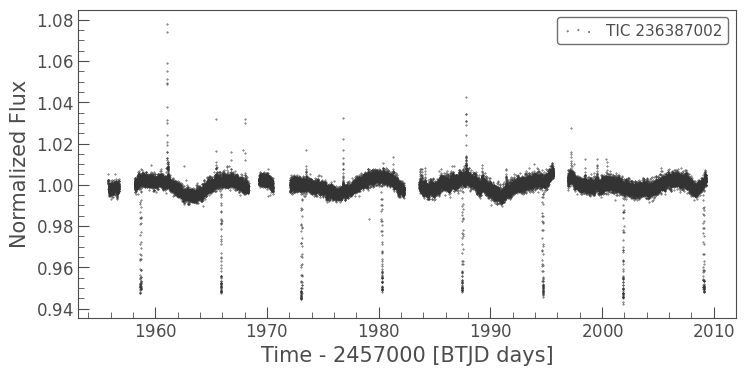

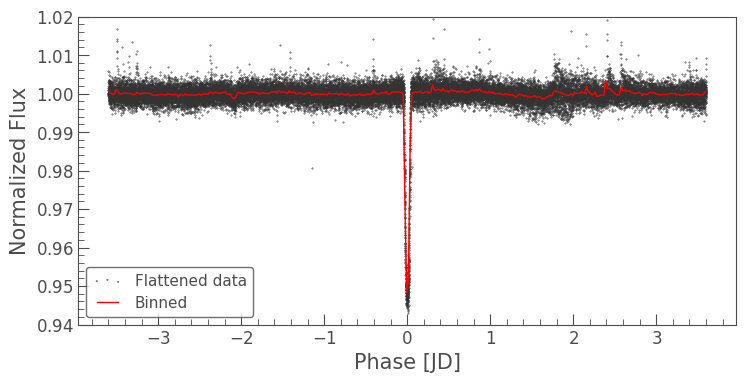

In [3]:
s=0.5
lcf = search_result.download_all()   # using the sector 24  just like the paper https://doi.org/10.1093/mnras/stac1666

lcf = lcf.stitch()
lcf.scatter(s=s)
# # lcf.remove_outliers().plot(label='Removing outliers')
# # lcf = lcf.stitch().normalize().remove_outliers()
# # lcf[0].plot(ax=ax, column='pdcsap_flux', normalize=True, label="PDCSAP");

lcf = lcf.remove_outliers(sigma=13) #sigma=11)  # giving bad dip (gives two lines instead of perfect dip)
# lcf.scatter(s=s, label='PDCSAP Flux (Normalized, and removed outliers)')#, normalize=True)

period = 7.2008652
epoch_time = 2458958.678060 - 2457000  # 2458958.678060
window_length =  2160 # 1440 #720 #int(1.0 / (np.median(np.diff(lcf.time.value))) * 1440)  # 1 day in points (~720 points for 2-min cadence)
lcf_flatten = lcf.flatten(window_length=window_length).fold(period = 7.2008652,  epoch_time = epoch_time) #.scatter(s=s, label='Flattened data')
# lcf.remove_nans().flatten(window_length=window_length).fold(period = 7.2008652,  epoch_time = epoch_time).bin(time_bin_size=30/24/60).plot(color="red", linewidth=1, label='Binned'); # Bin to 0.01 days (~14 minutes)
lcf_bin = lcf_flatten.bin(time_bin_size=30/60/24) #.plot(color="red", linewidth=1, label='Binned') # Bin to 0.01 days (~14 minutes)

ax = lcf_flatten.scatter(s=s, label='Flattened data')  # Plot folded light curve
lcf_bin.plot(ax=ax, label="Binned", color="red", linewidth=1)  # Plot binned LC on the same axis
ax.set_ylim(0.94, 1.02)

/var/folders/b_/91swq2f51r35gl42858jqwd00000gn/T/ipykernel_13117/2494032685.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{tick * 24:.1f}" for tick in ticks])  # Convert ticks to hours


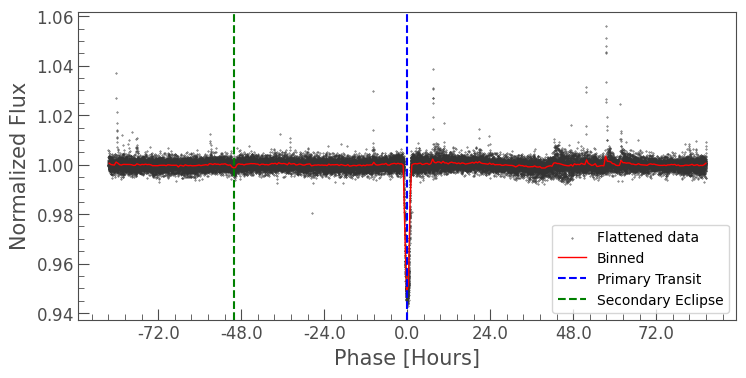

In [4]:
# plt.figure(figsize=(20, 6))
# ax = plt.gca()

ax = lcf_flatten.scatter(s=s, label='Flattened data')  # Plot folded light curve
lcf_bin.plot(ax=ax, label="Binned", color="red", linewidth=1)  # Plot binned LC on the same axis

# Convert x-axis from phase [JD] to hours (1 day = 24 hours)
ax.set_xlabel("Phase [Hours]")
ticks = ax.get_xticks()  # Get current x-axis ticks (in days)
ax.set_xticklabels([f"{tick * 24:.1f}" for tick in ticks])  # Convert ticks to hours

# Set y-axis limits as before
# ax.set_ylim(0.94, 1.02)
# ax.set_ylim(0.994,1.005)
# ax.set_xlim(-2.3, -1.9)

# Add vertical lines for primary transit and secondary eclipse
ax.axvline(x=0, color='blue', linestyle='--', label='Primary Transit')
ax.axvline(x=-2.09, color='green', linestyle='--', label='Secondary Eclipse')  # Phase -2 days = -48 hours
# ax.axvline(x=2.09, color='green', linestyle='--*')  # Phase -2 days = -48 hours

# ax.figure.set_size_inches(20, 6)  # Set figure size
ax.legend()
plt.show()



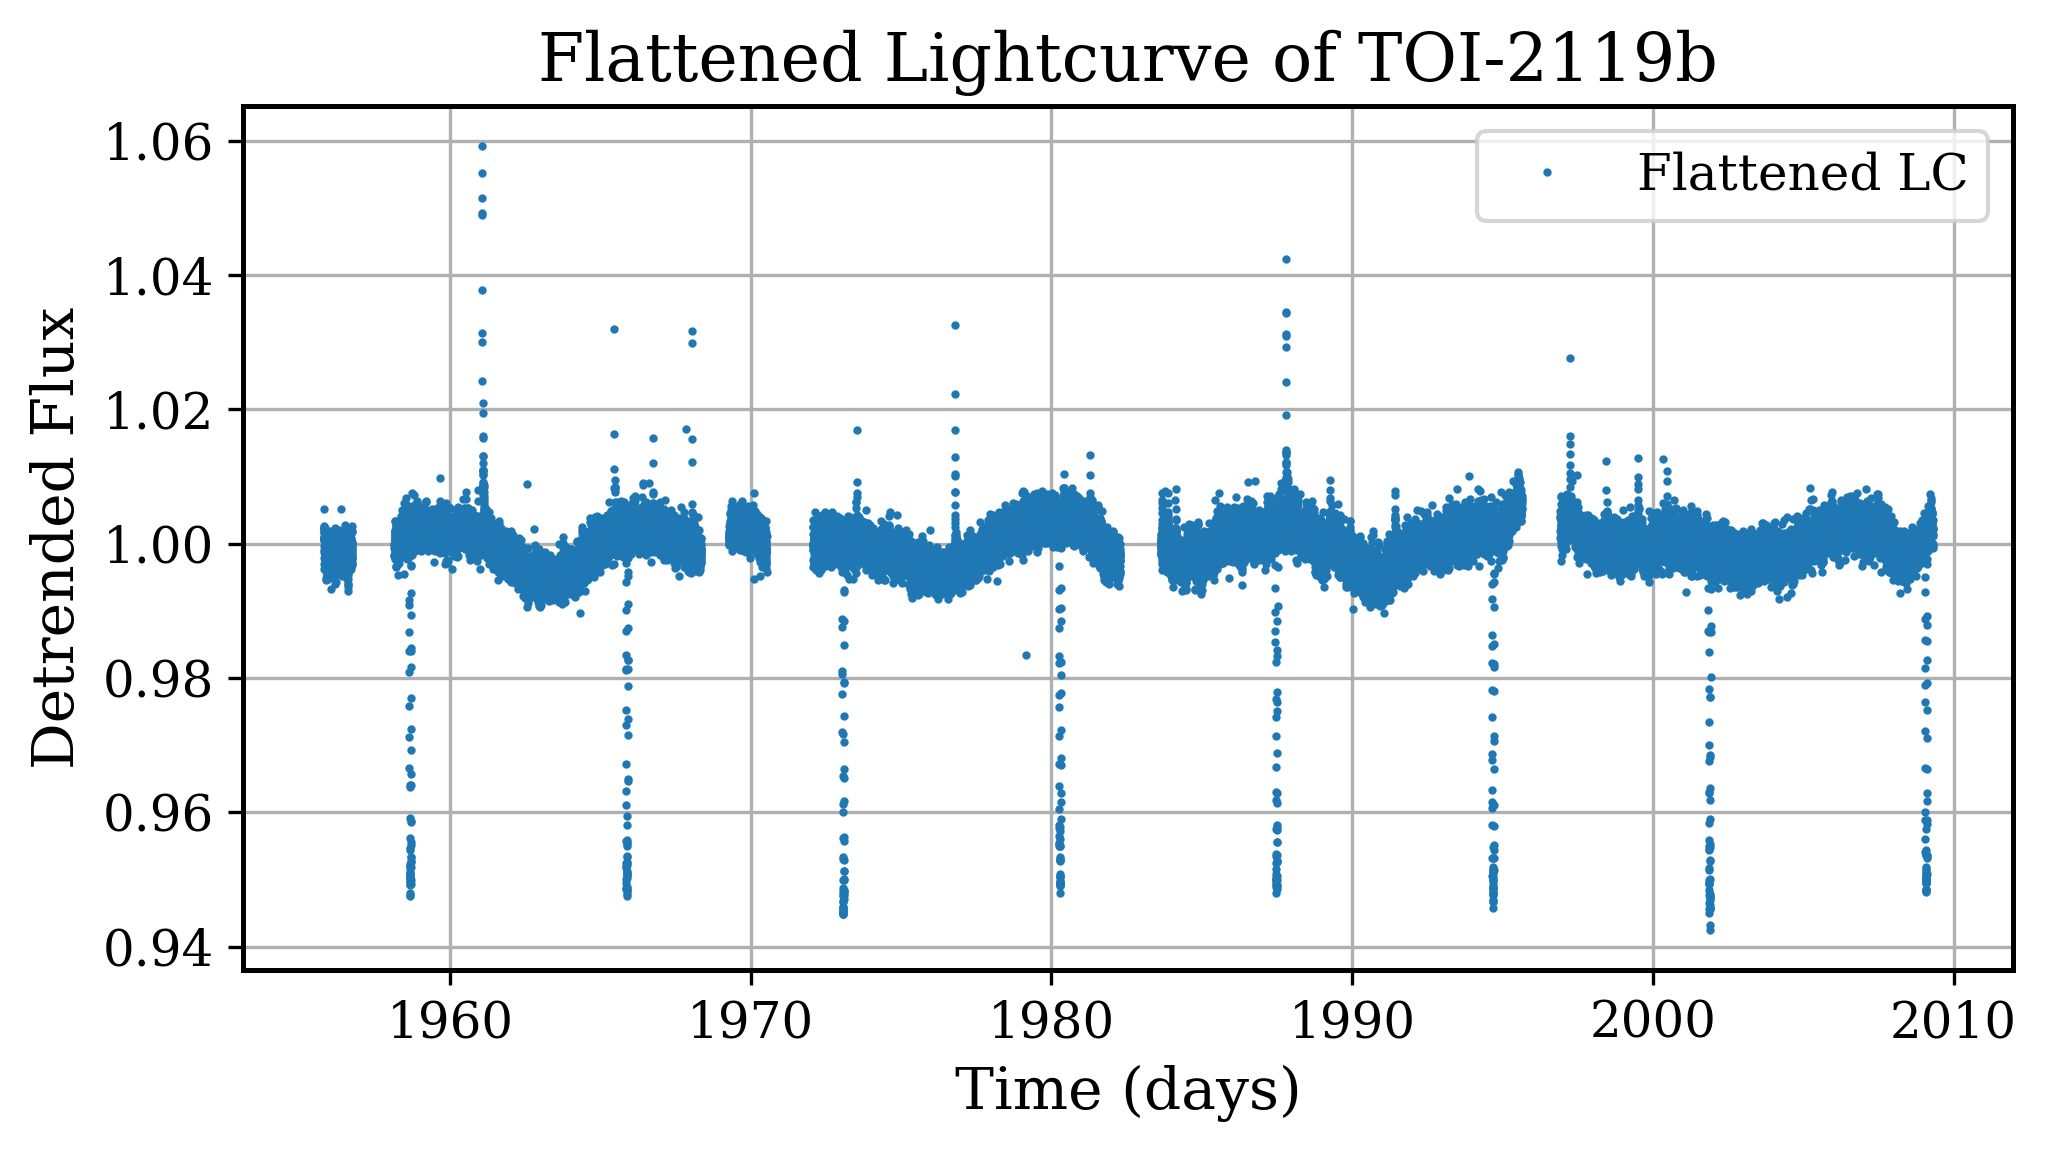

In [26]:
time = lcf.time.value
flux = lcf.flux.value
flux_err = lcf.flux_err.value
# flux

per, per_err = 7.2008652, 0.0000019    
bjd0, bjd0_err = 2458958.678060 - 2457000, 0.0002167

plt.figure(figsize=(7, 4))
plt.plot(time, flux, '.', markersize=2, label='Flattened LC')
# plt.scatter(time[~f_clipped.mask], f_clipped.data[~f_clipped.mask], s=2)
plt.xlabel('Time (days)')
plt.ylabel('Detrended Flux')
plt.title('Flattened Lightcurve of TOI-2119b')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [27]:
# flux
# Convert to plain numpy arrays and mask bad values
time = np.array(time.data)[~time.mask] if hasattr(time, 'mask') else np.array(time)
flux = np.array(flux.data)[~flux.mask] if hasattr(flux, 'mask') else np.array(flux)
flux_err = np.array(flux_err.data)[~flux_err.mask] if hasattr(flux_err, 'mask') else np.array(flux_err)

In [29]:
# Identify and filter out any NaN or infinite values in time, flux, and flux_err
valid_indices = np.isfinite(time) & np.isfinite(flux) & np.isfinite(flux_err)

# Apply the mask to remove any NaN or infinite values
time_cleaned = time[valid_indices]
flux_cleaned = flux[valid_indices]
flux_err_cleaned = flux_err[valid_indices]

sorted_indices = np.argsort(time_cleaned)
time_sorted = time_cleaned[sorted_indices]
flux_sorted = flux_cleaned[sorted_indices]
flux_err_sorted = flux_err_cleaned[sorted_indices]

tim, fl, fle = {}, {}, {}
# tim['TESS'], fl['TESS'], fle['TESS'] = time, flux, flux_err
tim['TESS'], fl['TESS'], fle['TESS'] = time_sorted, flux_sorted, flux_err_sorted

# putting parameters of TOI 2119.01 from literature
per, per_err = 7.2008652, 0.0000019    
bjd0, bjd0_err = 2458958.678060 - 2457000, 0.0002167

cycle = round((time[-1] - bjd0)/per)
tc1 = np.random.normal(bjd0, bjd0_err, 100000) + cycle*np.random.normal(per, per_err, 100000)
tc0, tc0_err = np.median(tc1), np.std(tc1)


tc2 = 2458956.5908#tc1 + np.random.normal(per, per_err, 100000)/2    ## eclipse time
tc_ecl, tc_ecl_err = np.median(tc2), np.std(tc2)

# Priors    #worked
par_P = ['P_p1', 't0_p1', 'p_p1_TESS', 'b_p1', 'q1_TESS', 'q2_TESS',\
     'a_p1', 'fp_p1_TESS', 't_secondary_p1', 'ecc_p1', 'omega_p1']
dist_P = ['normal', 'normal', 'uniform', 'uniform', 'uniform', 'uniform',\
     'loguniform', 'uniform', 'normal', 'uniform', 'uniform']
hyper_P = [[per, per_err], [tc0, 0.1], [0., 1.], [0., 1.], [0.,1.], [0.,1.],\
     [1., 10.], [1e-6, 1053e-6], [tc_ecl, tc_ecl_err], [0., 0.4], [0., 360.0]]


par_ins = ['mdilution_TESS', 'mflux_TESS', 'sigma_w_TESS']
dist_ins = ['fixed', 'normal', 'loguniform']
hyper_ins = [1., [0., 0.1], [0.1, 10000.]]

par_gp = ['GP_sigma_TESS', 'GP_timescale_TESS', 'GP_rho_TESS']
dist_gp = ['loguniform', 'loguniform', 'loguniform']
hyper_gp = [[1e-5, 10000.], [1e-3, 1e2], [1e-3, 1e2]]

par_tot = par_P + par_ins + par_gp
dist_tot = dist_P + dist_ins + dist_gp
hyper_tot = hyper_P + hyper_ins + hyper_gp

priors_tot = juliet.utils.generate_priors(par_tot, dist_tot, hyper_tot)

In [30]:
# Fitting

dataset = juliet.load(priors=priors_tot, t_lc=tim, y_lc=fl, yerr_lc=fle,\
                      GP_regressors_lc=tim, out_folder=os.getcwd() + '/Juliet_Analysis_TOI2119/Transit-Eclipse-ecc')
res = dataset.fit(sampler='dynesty', nthreads=8, verbose=True)

40248it [34:59, 19.17it/s, +500 | bound: 489 | nc: 1 | ncall: 1412004 | eff(%):  2.887 | loglstar:   -inf < 160178.648 <    inf | logz: 160098.713 +/-    nan | dlogz:  0.001 >  0.509]


In [32]:
os.system("cat Juliet_Analysis_TOI2119/Transit-Eclipse-ecc/posteriors.dat")

# Parameter Name     	 	 Median       	 	 Upper 68 CI  	 	 Lower 68 CI 
P_p1               	 	 7.2008653882 	 	 0.0000018370 	 	 0.0000018723
t0_p1              	 	 2009.0842172049 	 	 0.0004091748 	 	 0.0004088503
p_p1_TESS          	 	 0.2982180797 	 	 0.0088077546 	 	 0.0082483451
b_p1               	 	 0.8344202024 	 	 0.0128396477 	 	 0.0120625568
q1_TESS            	 	 0.9987857279 	 	 0.0008932957 	 	 0.0018539666
q2_TESS            	 	 0.9987254642 	 	 0.0009514966 	 	 0.0019215505
a_p1               	 	 9.9969499434 	 	 0.0022222252 	 	 0.0049456381
fp_p1_TESS         	 	 0.0005344629 	 	 0.0003517840 	 	 0.0003494951
t_secondary_p1     	 	 nan 	 	 nan 	 	 nan
ecc_p1             	 	 0.3997379759 	 	 0.0001945649 	 	 0.0004088208
omega_p1           	 	 90.2257643544 	 	 2.0824437042 	 	 2.0248755448
mflux_TESS         	 	 -0.0001552034 	 	 0.0001768579 	 	 0.0001741836
sigma_w_TESS       	 	 2.1770874601 	 	 13.8048858870 	 	 1.9080256868
GP_sigma_TESS      	 	 0.0000101697 	 	

0

 0.0000002415 	 	 0.0000001244
GP_timescale_TESS  	 	 13.9355662738 	 	 0.4358155993 	 	 0.4880796622
GP_rho_TESS        	 	 6.1880695070 	 	 25.4897620778 	 	 4.2407467950


In [33]:
# Making model
model = res.lc.evaluate('TESS')
gp_model = res.lc.model['TESS']['GP']
transit_model = res.lc.model['TESS']['deterministic']
mflx = np.median(res.posteriors['posterior_samples']['mflux_TESS'])
sigw = np.median(res.posteriors['posterior_samples']['sigma_w_TESS'] * 1e-6)

In [34]:
# model_flux = model  # Model flux
# time_values = tim['TESS']  # Time values from your input data

# # Create a DataFrame to save it as CSV
# df = pd.DataFrame({
#     'Time': time_values,
#     'Model Flux': model_flux
# })

# # Save the DataFrame to a CSV file
# df.to_csv('model_data.csv', index=False)

import pickle

# Save the entire result object
with open('model_results.pkl', 'wb') as f:
    pickle.dump(res, f)
    
# Load the result object when you need to see the content
with open('model_results.pkl', 'rb') as f:
    res_loaded = pickle.load(f)


(1955.7989093824324, 2009.3088519112753)

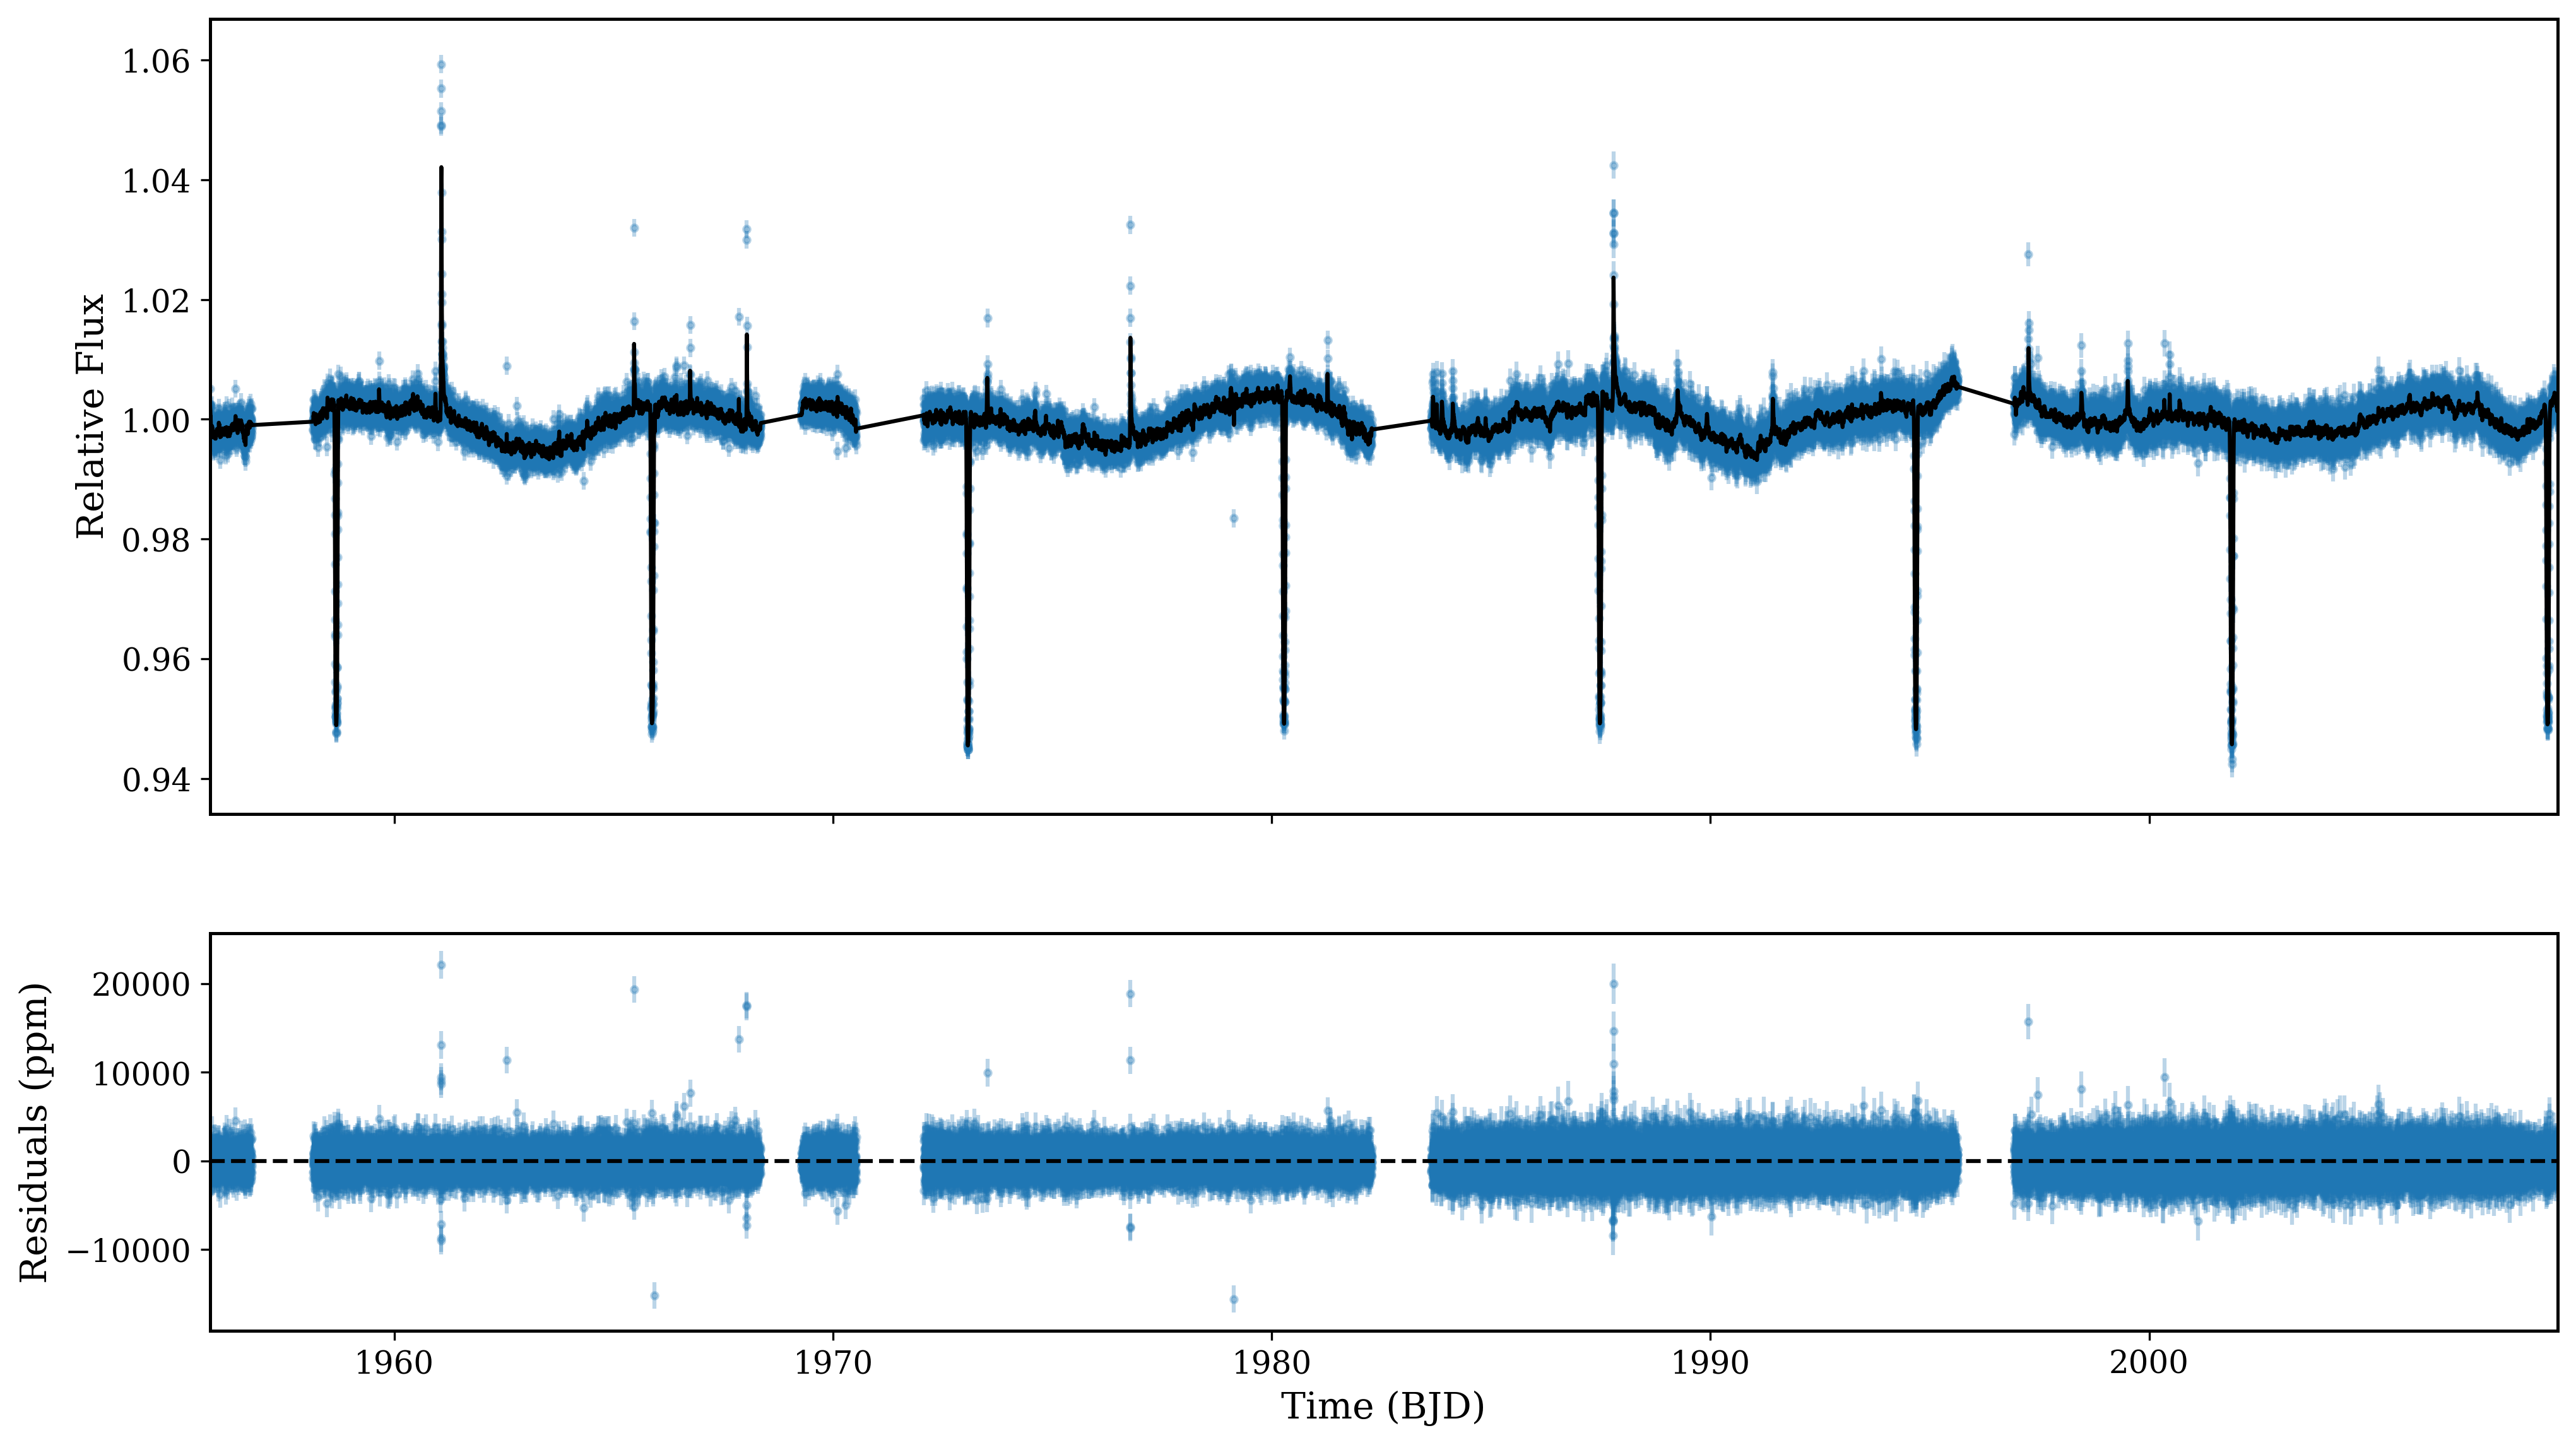

In [35]:
fig = plt.figure(figsize=(16,9))
gs = gd.GridSpec(2,1, height_ratios=[2,1])

# Lightcurve
ax1 = plt.subplot(gs[0])
ax1.errorbar(tim['TESS'], fl['TESS'], yerr=fle['TESS'], fmt='.', alpha=0.3)
ax1.plot(tim['TESS'], model, c='k', zorder=100)
ax1.set_ylabel('Relative Flux')
ax1.set_xlim(np.min(tim['TESS']), np.max(tim['TESS']))
ax1.xaxis.set_major_formatter(plt.NullFormatter())

# Residual
ax2 = plt.subplot(gs[1])
ax2.errorbar(tim['TESS'], (fl['TESS']-model)*1e6, yerr=fle['TESS']*1e6, fmt='.', alpha=0.3)
ax2.axhline(y=0.0, c='black', ls='--', zorder=100)
ax2.set_ylabel('Residuals (ppm)')
ax2.set_xlabel('Time (BJD)')
ax2.set_xlim(np.min(tim['TESS']), np.max(tim['TESS']))

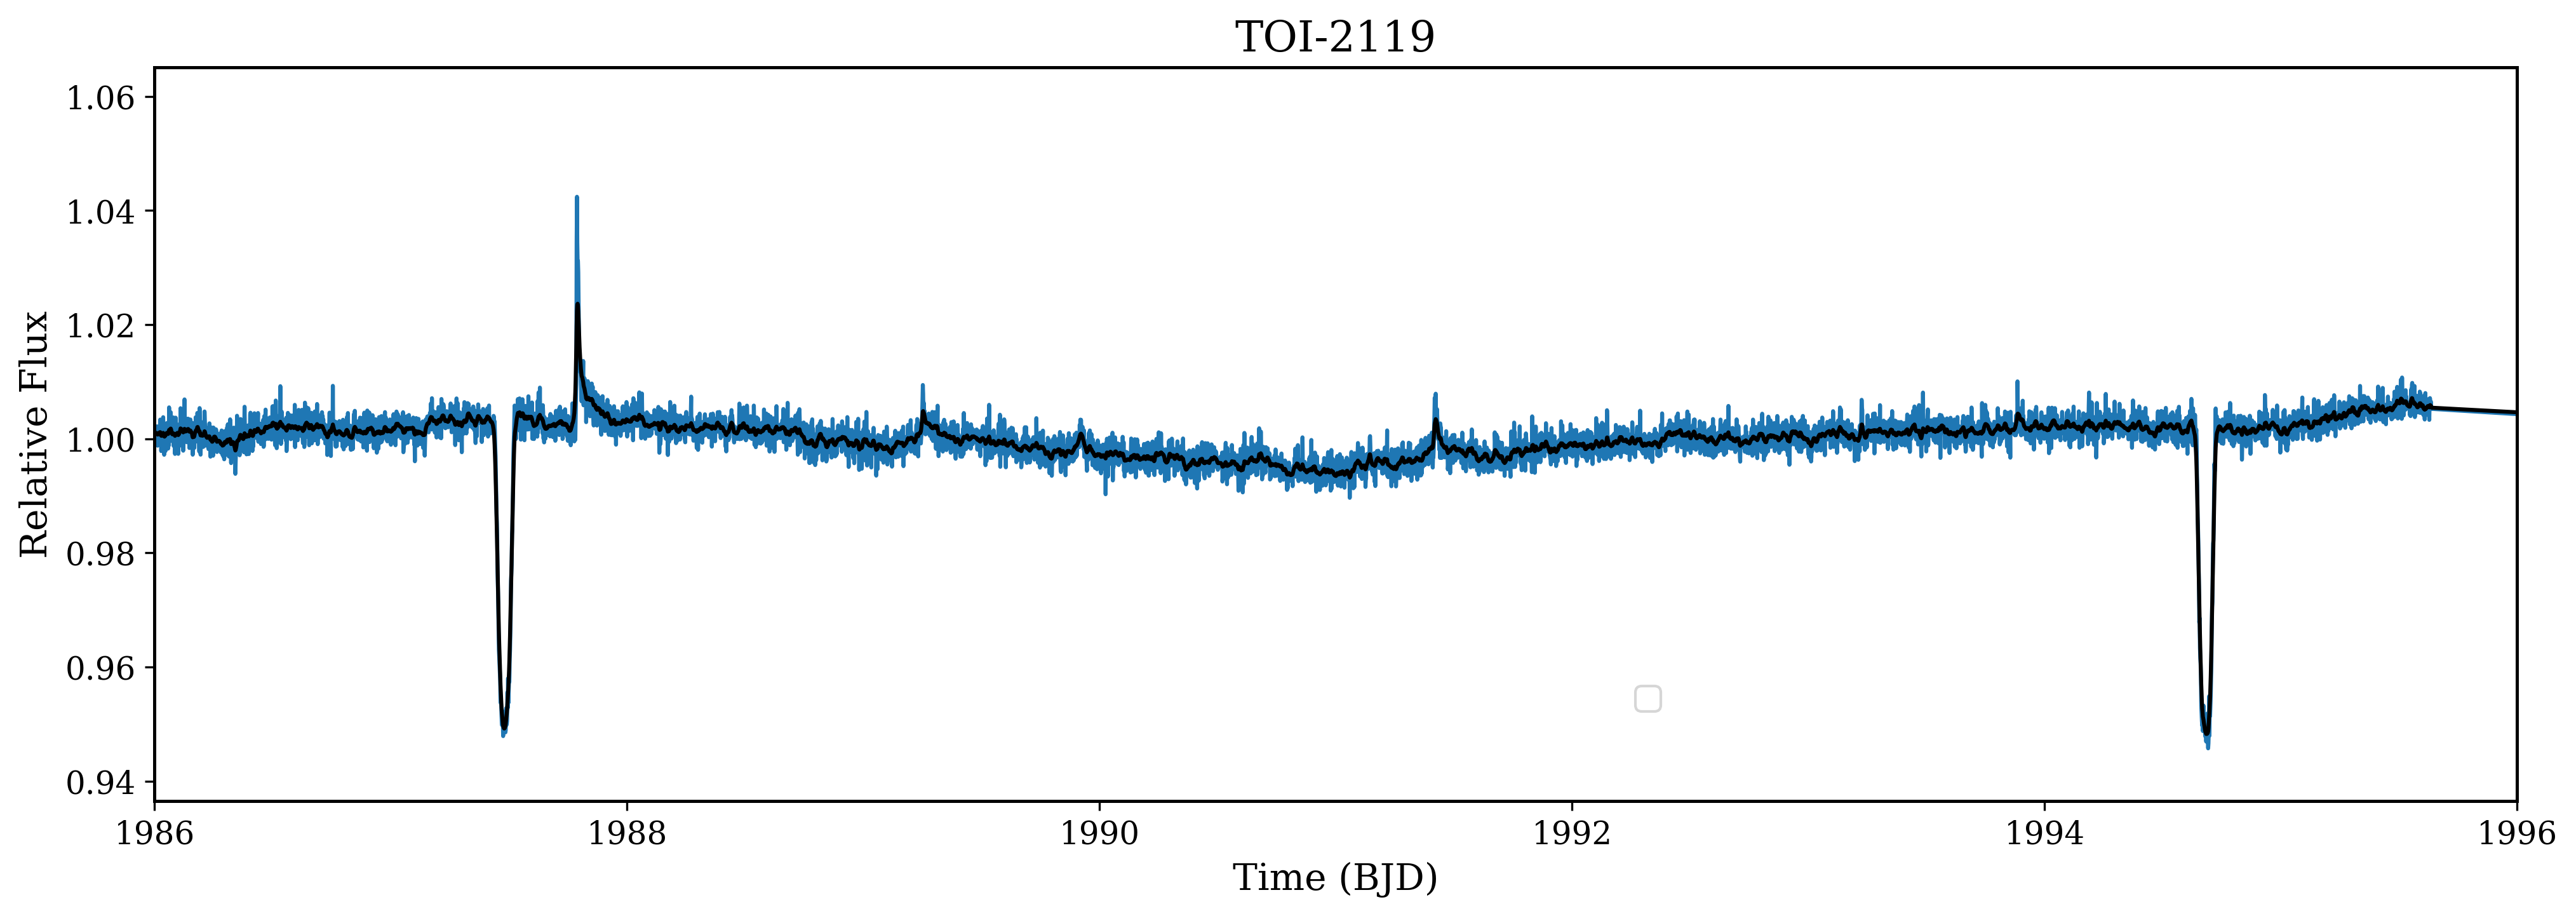

In [36]:
plt.figure(figsize=(16,5))
plt.plot(tim['TESS'], model, c='k', zorder=100)
plt.plot(tim['TESS'], fl['TESS'])#, '.') #, yerr=fle['TESS2'], fmt='.', alpha=0.3)

# tr1 = 1.9875 + 2.45836e6   # Transit
# x1 = 1.515 + 2.45836e6  # Eclipse1
# x2 = 2.46 + 2.45836e6   # Eclipse2
# # xt = (x2 - x1)/2
# y_gap2 = x2 - x1  # Choose a suitable y-coordinate for the horizontal line

# gap1 = tr1 - x1
# gap2 = x2 - tr1

# # Plot vertical lines
# plt.axvline(x=x1, color='red', linestyle='--', label="Eclipse1")
# plt.axvline(x=x2, color='green', linestyle='--', label="Eclipse2")
# plt.axvline(x=tr1, color='black', linestyle='--', label="Transit")

# plt.hlines(y=0.9867, xmin=x1+0.01, xmax=tr1-0.01, color='blue', linestyle='-')#, label="Gap")
# plt.text((x1 + tr1 ) / 2, 0.9865 + 0.001, f"Gap2 = {gap2:.2e}", color='blue', ha='center', fontsize=8)

# plt.hlines(y=0.9867, xmin=tr1+0.01, xmax=x2-0.01, color='brown', linestyle='-')#, label="Gap")
# plt.text((tr1 + x2) / 2, 0.9865 + 0.001, f"Gap1 = {gap1:.2e}", color='brown', ha='center', fontsize=8)

plt.xlim(1986, 1996)
plt.legend(loc="lower left", bbox_to_anchor=(0.62, 0.1))
plt.ylabel('Relative Flux')
plt.xlabel('Time (BJD)')
plt.title("TOI-2119")
plt.show()

Text(0.5, 0, 'Phases (days)')

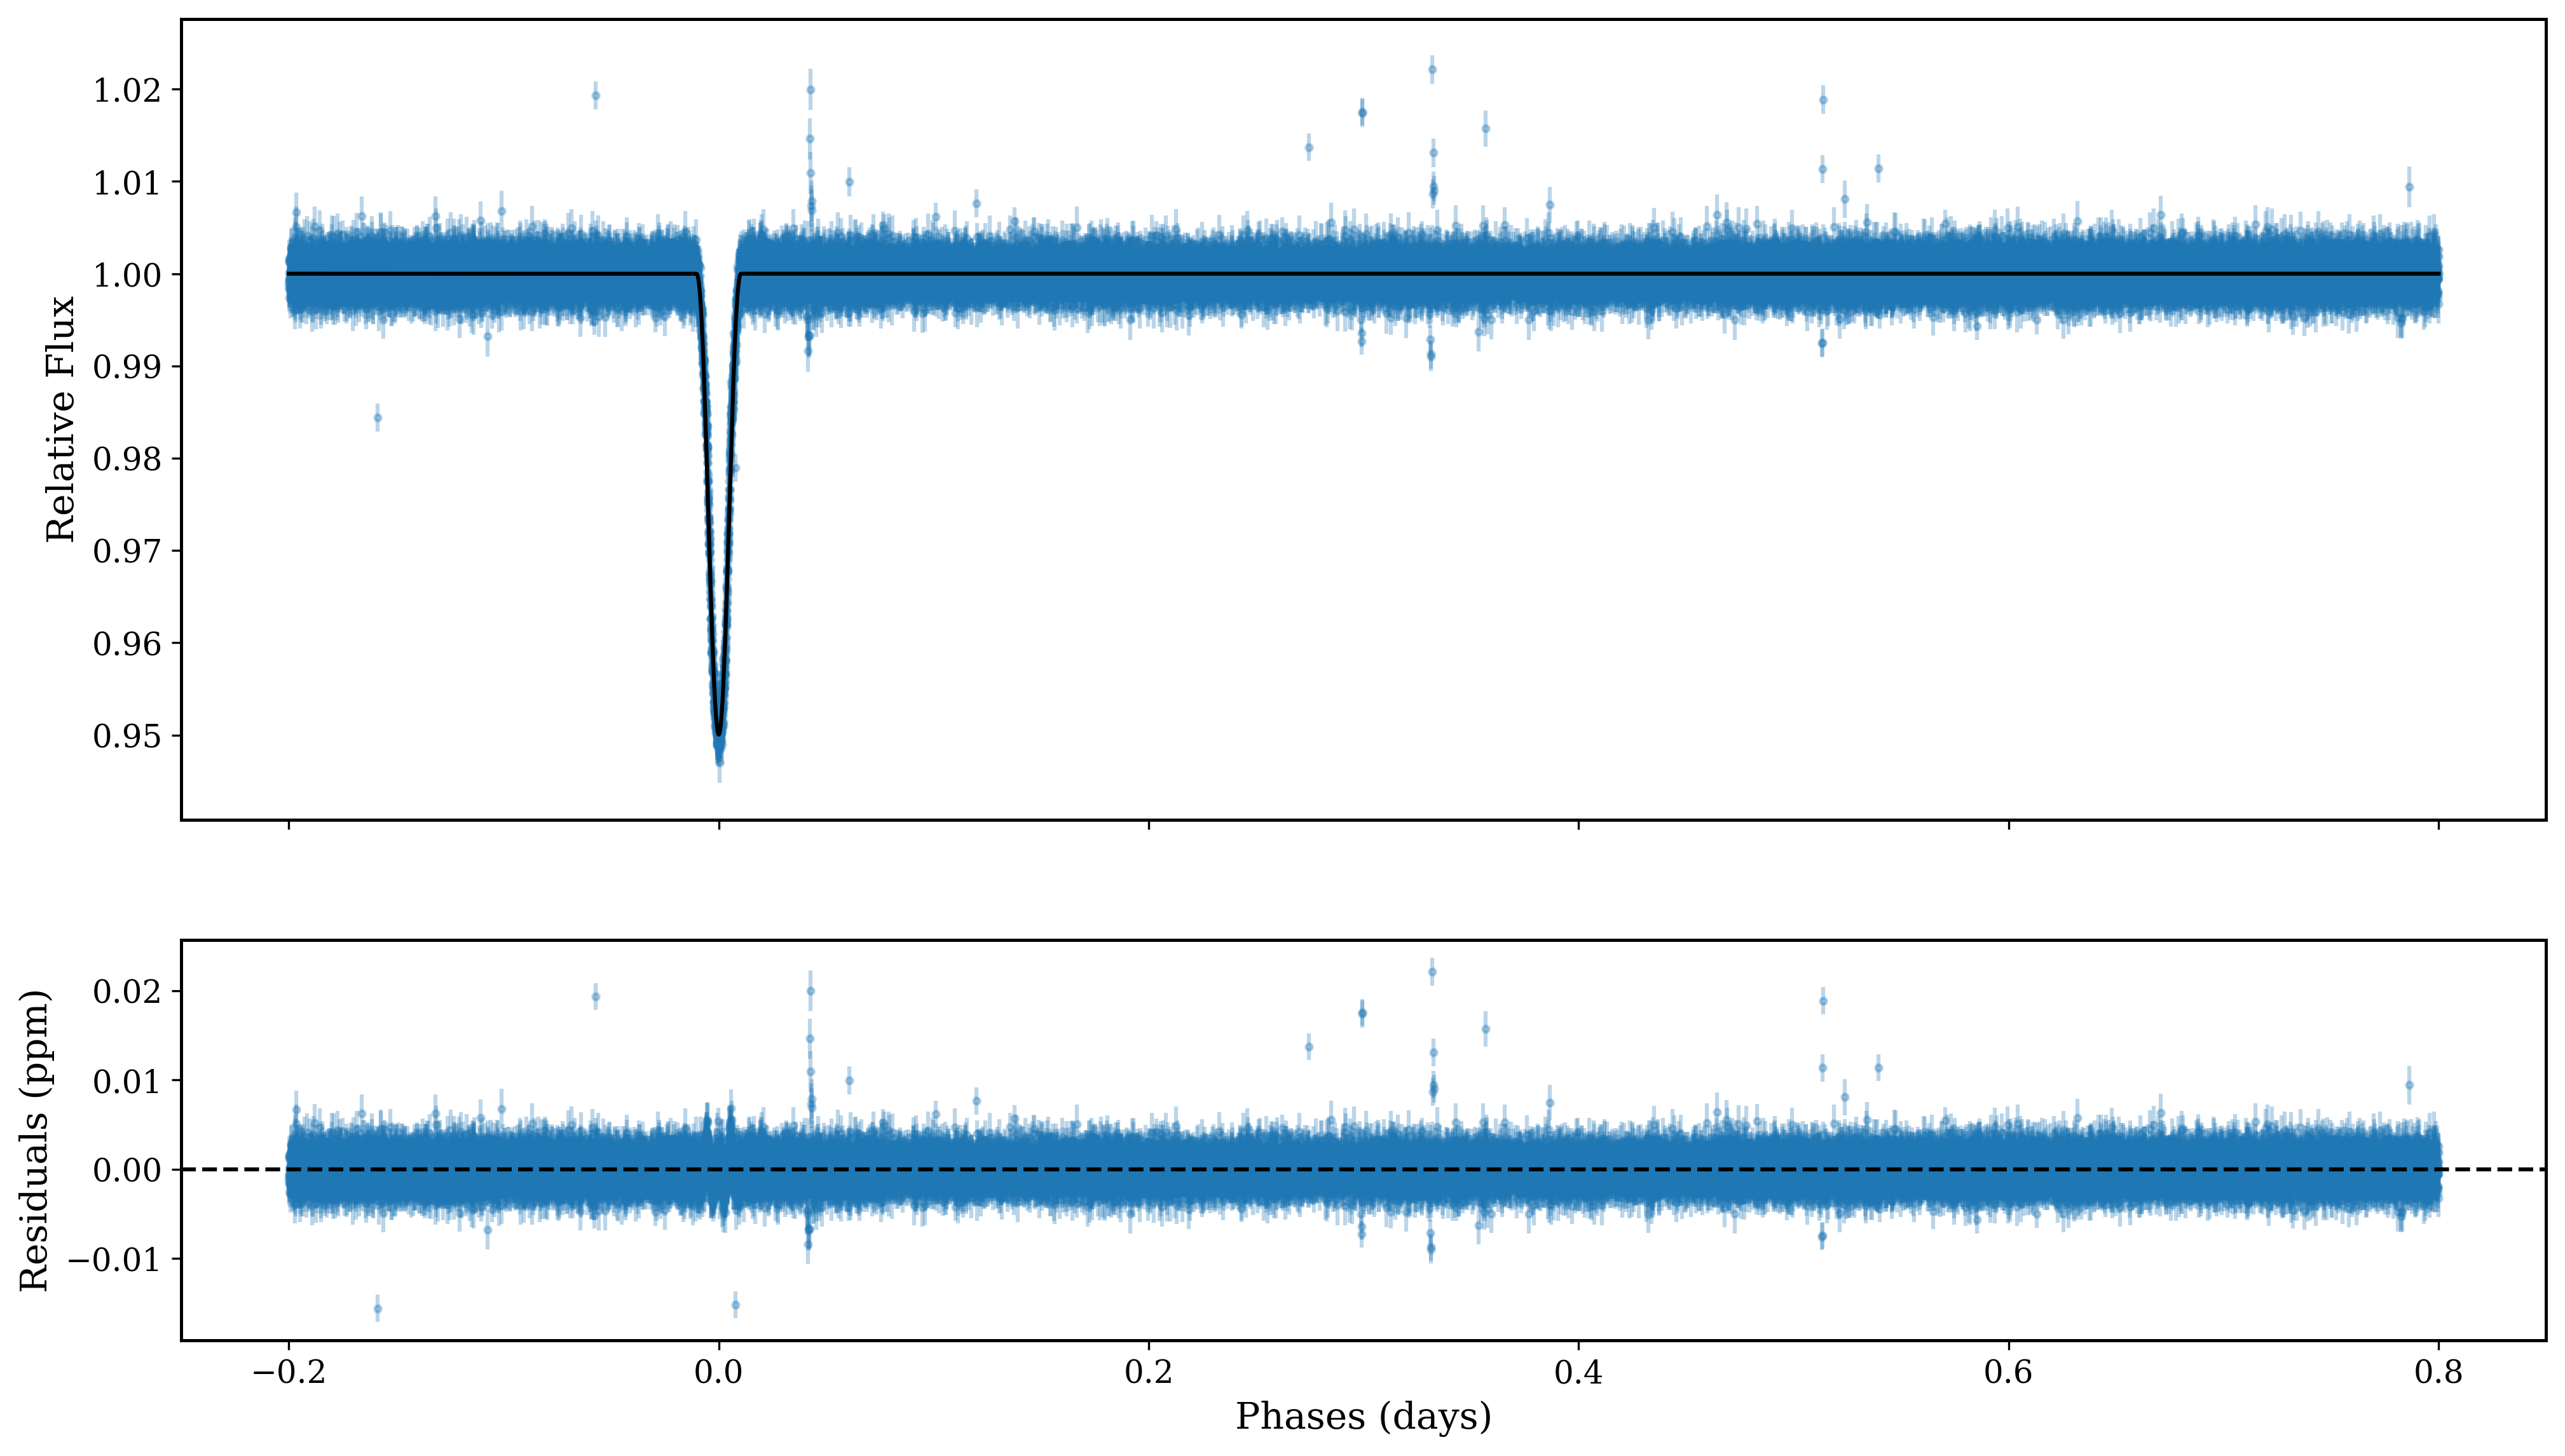

In [37]:
phs = juliet.utils.get_phases(tim['TESS'], per, bjd0, phmin=0.8)
idx = np.argsort(phs)

fig = plt.figure(figsize=(16,9))
gs = gd.GridSpec(2,1, height_ratios=[2,1])


ax1 = plt.subplot(gs[0])
ax1.errorbar(phs, (fl['TESS']-gp_model) * (1 + mflx), yerr=np.sqrt(fle['TESS']**2 + sigw**2),\
             fmt='.', alpha=0.3)
ax1.plot(phs[idx], transit_model[idx] * (1 + mflx), c='k', zorder=100)
# ax1.text(0.47, 0.996, "Eclipse.... Woohoo", fontsize=12, color='red')
ax1.set_ylabel('Relative Flux')
# ax1.set_xlim(-0.1, 0.6)
#ax1.set_ylim(0.998, 1.002)
ax1.xaxis.set_major_formatter(plt.NullFormatter())


ax2 = plt.subplot(gs[1])
ax2.errorbar(phs, (fl['TESS']-model), yerr=np.sqrt(fle['TESS']**2 + sigw**2),\
             fmt='.', alpha=0.3)
ax2.axhline(y=0.0, c='black', ls='--', zorder=100)
ax2.set_ylabel('Residuals (ppm)')
ax2.set_xlabel('Phases (days)')
# ax2.set_ylim(-2000, 2000)
# ax2.set_xlim(-0.1, 0.6)

### In this example too, in the top section, we can visually see the eclipse, and we were successful in getting the signature on the left around 48 hours before the transit. But modeling with juliet did not give us good confidence. Nonetheless, it is quite an interesting candidate. It is a brown dwarf around an active M-dwarf star, due to which we initially saw so much variations in the lightcurve, which was then removed with de-trending. It holds the capacity to give us more interesting results in future when we can observe its secondary eclipses.